# データサイエンス特論 第5回 演習課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302  森下剛

## 小テスト振り返り
- 標準偏差＝共分散 / 標準偏差の積
- AとBが同時に起こる確率（独立か不明の場合）：p(A|B)p(B)（Bが起こった時にAが起こる確率：p(A|B)）
- 累積分布関数：ある値以下になる確率を表す（確率分布からサンプルを引くときに使った（累積分布関数の逆関数？））

In [324]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import t

## 演習問題1

In [325]:
def norm_plot_fill_ci(mu, sigma, xrange, p):
    start = mu - xrange * sigma
    end = mu + xrange * sigma

    X = np.arange(start, end, 0.01)
    Y = norm.pdf(X, loc=mu, scale=sigma)

    fig, ax = plt.subplots()
    ax.plot(X, Y, color='blue')

    alpha = 1 - p
    x_lower = norm.ppf(alpha / 2, loc=mu, scale=sigma)
    x_upper = norm.ppf(1 - alpha / 2, loc=mu, scale=sigma)

    X_fill = np.arange(x_lower, x_upper, 0.001)
    Y_fill = norm.pdf(X_fill, loc=mu, scale=sigma)
    ax.fill_between(X_fill, Y_fill, alpha=0.5)

    ax.set_xlabel('X')
    ax.set_ylabel('Probability density')
    ax.set_title(f'{int(p*100)}% confidence interval: [{x_lower:.3f}, {x_upper:.3f}]')
    plt.show()

1.8973665961010275
1.959963984540054
95% 信頼区間: (np.float64(166.28122980617263), np.float64(173.71877019382737))


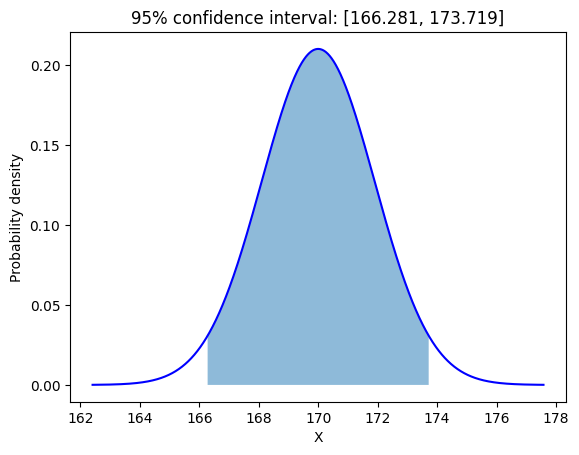

In [326]:
n = 10
mean = 170
sigma = np.sqrt(36)
se = sigma / np.sqrt(n)
print(se)

z_95 = norm.ppf(1 - 0.05 / 2)
print(z_95)
ci_95 = (mean - z_95 * se, mean + z_95 * se)
print(f'95% 信頼区間:', ci_95)

norm_plot_fill_ci(mu=mean, sigma=se, xrange=4, p=0.95)

90% 信頼区間: (np.float64(166.87910967274667), np.float64(173.12089032725333))


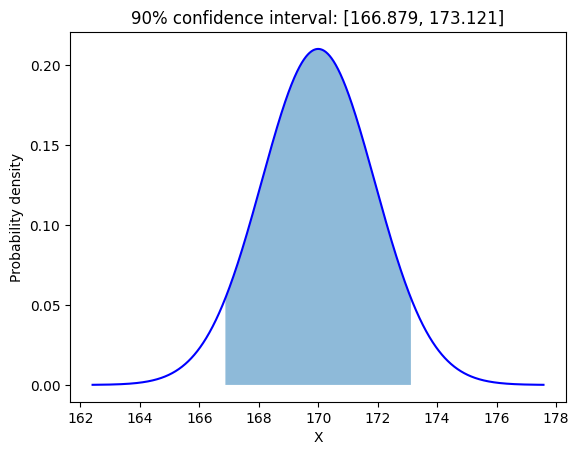

In [327]:
z_90 = norm.ppf(1 - 0.10 / 2)
ci_90 = (mean - z_90 * se, mean + z_90 * se)
print('90% 信頼区間:', ci_90)

norm_plot_fill_ci(mu=mean, sigma=se, xrange=4, p=0.90)

## 演習問題2

In [328]:
def t_plot_fill_ci(mu, sigma, df, xrange, p):
    start = mu - xrange * sigma
    end = mu + xrange * sigma

    X = np.arange(start, end, 0.01)
    Y = t.pdf(X, df=df, loc=mu, scale=sigma)

    fig, ax = plt.subplots()
    ax.plot(X, Y, color='blue')

    alpha = 1 - p
    x_lower = t.ppf(alpha / 2, df=df, loc=mu, scale=sigma)
    x_upper = t.ppf(1 - alpha / 2, df=df, loc=mu, scale=sigma)

    X_fill = np.arange(x_lower, x_upper, 0.001)
    ax.fill_between(X_fill, t.pdf(X_fill, df=df, loc=mu, scale=sigma), alpha=0.5)

    ax.set_xlabel('X')
    ax.set_ylabel('Probability density')
    ax.set_title(f'{int(p*100)}% confidence interval: [{x_lower:.3f}, {x_upper:.3f}]')
    plt.show()

95% 信頼区間: (np.float64(167.13857237611734), np.float64(172.86142762388266))


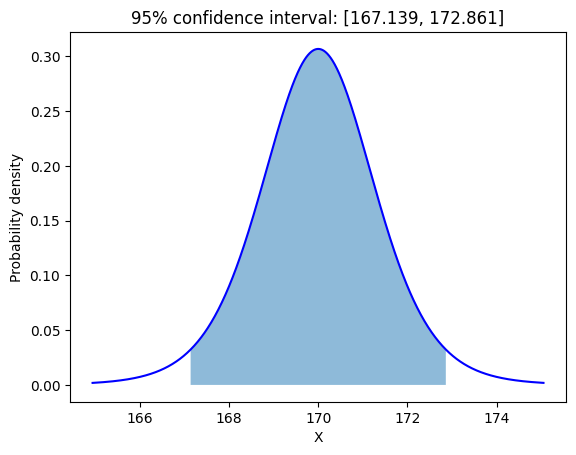

In [329]:
n = 10
mean = 170
s = np.sqrt(16)
se = s / np.sqrt(n)

t_95 = t.ppf(1 - 0.05 / 2, df=n-1)
ci_95 = (mean - t_95 * se, mean + t_95 * se)
print('95% 信頼区間:', ci_95)

t_plot_fill_ci(mu=mean, sigma=se, df=n-1, xrange=4, p=0.95)

90% 信頼区間: (np.float64(167.68127516979817), np.float64(172.31872483020183))


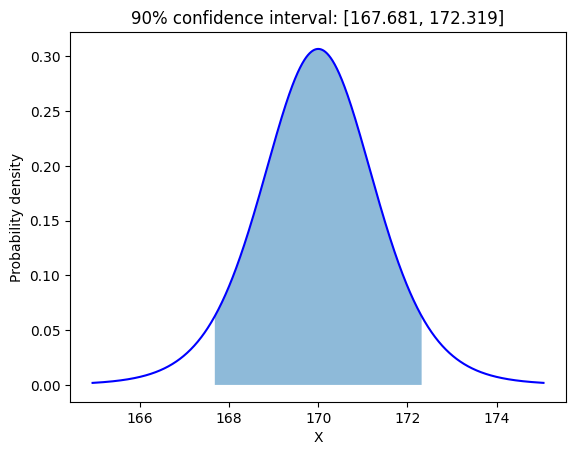

In [330]:
n = 10
mean = 170
s = np.sqrt(16)
se = s / np.sqrt(n)

t_90 = t.ppf(1 - 0.10 / 2, df=n-1)
ci_90 = (mean - t_90 * se, mean + t_90 * se)
print('90% 信頼区間:', ci_90)

t_plot_fill_ci(mu=mean, sigma=se, df=n-1, xrange=4, p=0.90)

## 演習問題3

In [331]:
def pmean_range(n, mu, sigma2, a):
    """母分散未知の正規母集団における母平均の信頼区間．

    Parameters
    ----------
    n : int      標本要素数
    mu : float   標本平均
    sigma2 : float   不偏分散
    a : float    信頼度（%）  例: 95 → 信頼度 95%
    """
    se = np.sqrt(sigma2) / np.sqrt(n)
    alpha = 1 - a / 100         # 信頼度（%）→ α
    t_a = t.ppf(1 - alpha / 2, df=n-1)

    return mu - t_a * se, mu + t_a * se

検証方法として Scipy の公式関数を用いる。

In [332]:
from scipy.stats import t

n, mu, sigma2 = 10, 170, 16
s = np.sqrt(sigma2)
se = s / np.sqrt(n)

# 公式関数
expected_95 = t.interval(0.95, df=n-1, loc=mu, scale=se)
print('scipy:', expected_95)

# 自作関数（a は % 指定）
print('自作:', pmean_range(n, mu, sigma2, 95))

scipy: (np.float64(167.13857237611734), np.float64(172.86142762388266))
自作: (np.float64(167.13857237611734), np.float64(172.86142762388266))


値が等しくなることから正しく実装できていることが確認できた。

## 演習問題4

In [333]:
from scipy.stats import chi2

In [334]:
def chi2_plot_fill_ci(df, xrange, p):
    mean = df
    spread = np.sqrt(2 * df)
    start = max(0, mean - xrange * spread)
    end = mean + xrange * spread

    X = np.arange(start, end, 0.01)
    Y = chi2.pdf(X, df=df)

    fig, ax = plt.subplots()
    ax.plot(X, Y, color='blue')

    alpha = 1 - p
    x_lower = chi2.ppf(alpha / 2, df=df)
    x_upper = chi2.ppf(1 - alpha / 2, df=df)

    X_fill = np.arange(x_lower, x_upper, 0.001)
    ax.fill_between(X_fill, chi2.pdf(X_fill, df=df), alpha=0.5)

    ax.set_xlabel('χ²')
    ax.set_ylabel('Probability density')
    ax.set_title(f'{int(p*100)}% range (df={df}): [{x_lower:.3f}, {x_upper:.3f}]')
    plt.show()

In [335]:
n = 100
sample_var = 14.85
df = n - 1
alpha = 0.10

s2 = n / (n - 1) * sample_var

chi2_5  = chi2.ppf(alpha / 2, df=df)
chi2_95 = chi2.ppf(1 - alpha / 2, df=df)
print(f'χ(n-1, 5)  = {chi2_5:.4f}')
print(f'χ(n-1, 95) = {chi2_95:.4f}')

ci_90 = ((n - 1) * s2 / chi2_95, (n - 1) * s2 / chi2_5)
print('90% 母分散の信頼区間:', ci_90)

χ(n-1, 5)  = 77.0463
χ(n-1, 95) = 123.2252
90% 母分散の信頼区間: (np.float64(12.051104331445993), np.float64(19.27411680838875))


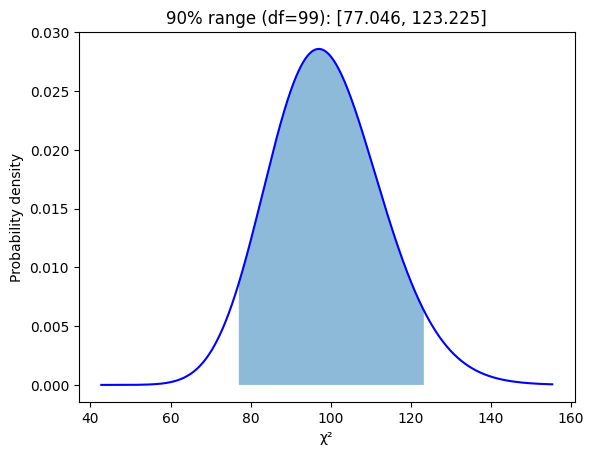

In [336]:
chi2_plot_fill_ci(df=n-1, xrange=4, p=0.90)

## 演習問題5

### 1. 信頼度を変化させたときの信頼区間

In [337]:
print('信頼度 50%:', pmean_range(10, 170, 16, 50))
print('信頼度 60%:', pmean_range(10, 170, 16, 60))
print('信頼度 70%:', pmean_range(10, 170, 16, 70))
print('信頼度 80%:', pmean_range(10, 170, 16, 80))
print('信頼度 90%:', pmean_range(10, 170, 16, 90))

信頼度 50%: (np.float64(169.11111898160908), np.float64(170.88888101839092))
信頼度 60%: (np.float64(168.88257268384396), np.float64(171.11742731615604))
信頼度 70%: (np.float64(168.60895681584634), np.float64(171.39104318415366))
信頼度 80%: (np.float64(168.250591646879), np.float64(171.749408353121))
信頼度 90%: (np.float64(167.68127516979817), np.float64(172.31872483020183))


信頼度を上げるほど信頼空間は広くなることが確認できた。

### 2. 標本の要素数を変化させたときに信頼区間

In [338]:
print('要素数 10:', pmean_range(10, 170, 16, 90))
print('要素数 100:', pmean_range(100, 170, 16, 90))
print('要素数 1000:', pmean_range(1000, 170, 16, 90))
print('要素数 10000:', pmean_range(10000, 170, 16, 90))
print('要素数 100000:', pmean_range(100000, 170, 16, 90))

要素数 10: (np.float64(167.68127516979817), np.float64(172.31872483020183))
要素数 100: (np.float64(169.3358435375932), np.float64(170.6641564624068))
要素数 1000: (np.float64(169.79174752854055), np.float64(170.20825247145945))
要素数 10000: (np.float64(169.93419975866755), np.float64(170.06580024133245))
要素数 100000: (np.float64(169.979193871738), np.float64(170.020806128262))


要素数nを増やすほど信頼空間が狭くなることが確認できた。